In [1]:
# import the usual suspects
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.utils import load_config,check_file_exists,print_balancing
import src.utils as utl

In [2]:
import dice_ml
import time

In [3]:
config = load_config("config.yaml")


In [4]:
dataset_name = 'toy_dataset'

In [5]:
data_processor = DataProcessor(config=config)


Loading toy_dataset dataset


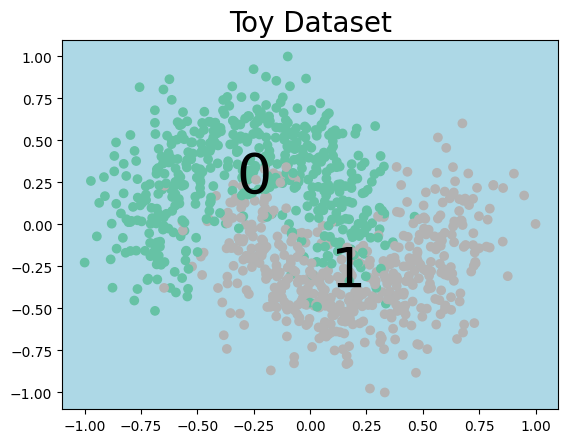

In [6]:
data = data_processor.load_dataset(dataset_name)

In [7]:
features = data.copy()
features.select_dtypes(include=['object', 'category']).columns

Index([], dtype='object')

In [8]:
processed_data = data_processor.preprocess_data(data,
                                                    dataset_name)
processed_data[0].head()

Starting preprocessing


,Feature1,Feature2
0,-0.728015,0.620098
1,0.826606,-0.888039
2,0.248392,-0.017534
3,-0.611659,-1.570259
4,-1.412665,0.544288


In [9]:
splits = data_processor.split_data(features=processed_data[0],
                                        target=processed_data[1])
for k,v in splits.items():
    print(k,v.shape)
    if type(v) == pd.Series:
        utl.print_balancing(splits[k])

Splitting data into train, test, and calibration sets
X_train shape: (550, 2) Percentage of total: 0.55
y_train shape: (550,) Percentage of total: 0.55
X_test shape: (250, 2) Percentage of total: 0.25
y_test shape: (250,) Percentage of total: 0.25
X_calibration shape: (200, 2) Percentage of total: 0.20
y_calibration shape: (200,) Percentage of total: 0.20
X_train (550, 2)
y_train (550,)
Balancing: 550 samples
|██████████          | class 0: 275 (50.0%)
|          ██████████| class 1: 275 (50.0%)

X_test (250, 2)
y_test (250,)
Balancing: 250 samples
|██████████          | class 0: 125 (50.0%)
|          ██████████| class 1: 125 (50.0%)

X_calibration (200, 2)
y_calibration (200,)
Balancing: 200 samples
|██████████          | class 0: 100 (50.0%)
|          ██████████| class 1: 100 (50.0%)



In [10]:
splits_path = f"data/processed/{dataset_name}/y_train.npz"
if not check_file_exists(splits_path):
    print(splits_path,"not found")
    print("Processing dataset")
    data = data_processor.load_dataset(dataset_name)
    processed_data = data_processor.preprocess_data(data,
                                                    dataset_name)
    splits = data_processor.split_data(features=processed_data[0],
                                        target=processed_data[1])
    data_processor.save_splits(splits, dataset_name)
else:
    print("Loading existing dataset")
    splits = data_processor.load_splits(dataset_name)

# print the balance of the splits
print("Train balance: \n")
print_balancing(splits['y_train'])
print("Test balance: \n")
print_balancing(splits['y_test'])
print("Calibration balance: \n")
print_balancing(splits['y_calibration'])



Loading existing dataset
Loaded feature names from data/processed/toy_dataset/feature_names.csv
Loaded X_train from data/processed/toy_dataset/X_train.npz
Loaded y_train from data/processed/toy_dataset/y_train.npz
Loaded X_test from data/processed/toy_dataset/X_test.npz
Loaded y_test from data/processed/toy_dataset/y_test.npz
Loaded X_calibration from data/processed/toy_dataset/X_calibration.npz
Loaded y_calibration from data/processed/toy_dataset/y_calibration.npz
Train balance: 

Balancing: 550 samples
|██████████          | class 0: 275 (50.0%)
|          ██████████| class 1: 275 (50.0%)

Test balance: 

Balancing: 250 samples
|██████████          | class 0: 125 (50.0%)
|          ██████████| class 1: 125 (50.0%)

Calibration balance: 

Balancing: 200 samples
|██████████          | class 0: 100 (50.0%)
|          ██████████| class 1: 100 (50.0%)



(array([0, 1]), array([100, 100]))

In [11]:
'''
'''
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
dt =RandomForestClassifier(max_depth=4)
dt.fit(splits['X_train'],splits['y_train'])
models = {"decision_tree": dt}

In [12]:
dataset_name

'toy_dataset'

In [13]:
dt_name = dataset_name

In [14]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name,
                                    which_models="mlp")#"random_forest")
print(models.keys())
chosen_model = list(models.keys())[0]

Processing mlp for toy_dataset
Loaded mlp model from models/toy_dataset/mlp.pkl
Loaded existing mlp model
dict_keys(['mlp'])


In [15]:
my_model = models[chosen_model]
print(model_trainer._evaluate_on_test_set(models["mlp"],splits['X_test'],splits['y_test']))
print(model_trainer._evaluate_on_test_set(models["mlp"],splits['X_calibration'],splits['y_calibration']))
print("\n","\t"*5,"VVVVV TRAIN VVVVV")
print(model_trainer._evaluate_on_test_set(models["mlp"],splits['X_train'],splits['y_train']))

{'test_balanced_accuracy': 0.912, 'test_f1_score_w': 0.912, 'test_accuracy': 0.912}
{'test_balanced_accuracy': 0.905, 'test_f1_score_w': 0.9049976249406234, 'test_accuracy': 0.905}

 					 VVVVV TRAIN VVVVV
{'test_balanced_accuracy': 0.9072727272727272, 'test_f1_score_w': 0.9072724207352751, 'test_accuracy': 0.9072727272727272}


In [16]:
models[chosen_model]

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MLPClassifier(hidden_layer_sizes=[32], learning_rate_init=0.1,
                               max_iter=500))])

In [17]:
reference_set = splits['X_train'].copy()
feat_names = splits['X_train'].columns.to_list()
target_name = data_processor.target_name
# we add the target variable to the reference set
reference_set[target_name] = splits['y_train']
# 
# reference_set[target_name]
# make it categorical
reference_set[target_name] = reference_set[target_name].astype('category')

In [18]:
import importlib
import src.cf_generator_lore as flx
from src.cf_generator_lore  import *
#
importlib.reload(flx)


<module 'src.cf_generator_lore' from '/home/vbonsignori/L2loRe/src/cf_generator_lore.py'>

In [19]:
config["counterfactuals"]["growing_spheres"]
config["counterfactuals"]["growing_spheres"]

{'n_in_layer': 200,
 'first_radius': 0.05,
 'dicrease_radius': 2.0,
 'sparse': True}

## The GS Generator

In [20]:
from src.growingspheres.growingspheres import counterfactuals as cf

In [21]:
from src.cf_generator_gs import GrowingSpheresCFGenerator

In [22]:

#cf_generator = DiceCFGenerator(config=config)
cf_generator = GrowingSpheresCFGenerator(config=config,dataset_name=dataset_name)

In [23]:
reference_set = splits['X_train'].copy()
feat_names = splits['X_train'].columns.to_list()
target_name = data_processor.target_name
# we add the target variable to the reference set
reference_set[target_name] = splits['y_train']
cf_generator.setup(
    reference_data=reference_set,
    #feature_names=feat_names,
    continuous_features = feat_names,
    categorical_features=[],#data_processor.categorical_features,
    target_name=target_name,
)
print("Generating counterfactuals")

Generating counterfactuals


In [24]:
counterfactuals = cf_generator.generate_counterfactuals(
        models=models,
        X_calibration=splits['X_calibration'][:].copy(),
        y_calibration=splits['y_calibration'][:].copy(),
        num_cf=16,
        dt_name=dataset_name,
        set_name="calibration"
    )

Generating CFs with with method: (abstract) for model: mlp
sample 0 1.12
sample 1 1.0
sample 2 1.06
sample 3 1.0
sample 4 1.0
sample 5 1.0
sample 6 1.12
sample 7 1.06
sample 8 1.12
sample 9 1.0
sample 10 1.0
sample 11 1.0
sample 12 1.0
sample 13 1.94
sample 14 1.25
sample 15 1.06
sample 16 1.0
sample 17 1.06
sample 18 1.06
sample 19 1.06
sample 20 1.0
sample 21 1.12
sample 22 1.12
sample 23 1.0
sample 24 1.0
sample 25 1.0
sample 26 1.0
sample 27 1.0
sample 28 1.06
sample 29 1.0
sample 30 1.0
sample 31 1.0
sample 32 1.19
sample 33 1.0
sample 34 1.0
sample 35 1.12
sample 36 1.0
sample 37 1.0
sample 38 1.06
sample 39 1.0
sample 40 1.06
sample 41 1.06
sample 42 1.0
sample 43 1.0
sample 44 1.19
sample 45 1.06
sample 46 1.06
sample 47 1.12
sample 48 1.06
sample 49 1.0
sample 50 1.0
sample 51 1.0
sample 52 1.0
sample 53 1.06
sample 54 1.0
sample 55 1.0
sample 56 1.0
sample 57 1.0
sample 58 1.0
sample 59 1.0
sample 60 1.0
sample 61 1.0
sample 62 1.0
sample 63 1.0
sample 64 1.0
sample 65 1.06
s

In [26]:
counterfactuals

{'mlp': [{'instance_idx': 0,
   'original_instance':    Feature1  Feature2
   0 -0.987172  1.146316,
   'true_class': 0    0
   Name: 0, dtype: int64,
   'counterfactuals':            0         1  target
   0  -0.461809  0.672423       1
   1  -0.536827  0.584988       1
   2  -0.483755  0.630828       1
   3  -0.431338  0.666545       1
   4  -0.464436  0.679952       1
   5  -0.531845  0.601628       1
   6  -0.450622  0.689297       1
   7  -0.472085  0.676985       1
   8  -0.454630  0.674172       1
   9  -0.445438  0.712301       1
   10 -0.515289  0.601470       1
   11 -0.527602  0.588131       1
   12 -0.473481  0.649481       1
   13 -0.479236  0.657667       1
   14 -0.528194  0.581982       1
   15 -0.440832  0.698476       1
   16 -0.477199  0.606195       1
   17 -0.551181  0.539063       1},
  {'instance_idx': 1,
   'original_instance':    Feature1  Feature2
   1  0.629517 -1.176607,
   'true_class': 0    1
   Name: 1, dtype: int64,
   'counterfactuals':            0    

In [36]:
counterfactuals["mlp"][6]

{'instance_idx': 6,
 'original_instance':    Feature1  Feature2
 6  0.629721  0.716841,
 'true_class': 0    0
 Name: 6, dtype: int64,
 'counterfactuals':            0         1  target
 0   1.099650  0.716841       1
 1   1.101468  0.716841       1
 2   1.098370  0.716841       1
 3   1.104195  0.716841       1
 4   1.108639  0.716841       1
 5   1.085666  0.556295       1
 6   1.113821  0.716841       1
 7   1.095374  0.716841       1
 8   1.093014  0.697209       1
 9   1.121145  0.716841       1
 10  1.120127  0.716841       1
 11  1.095801  0.716841       1
 12  1.099832  0.716841       1
 13  1.107501  0.716841       1
 14  1.102340  0.716841       1
 15  1.101939  0.716841       1
 16  1.110033  0.716841       1
 17  1.107028  0.716841       1}

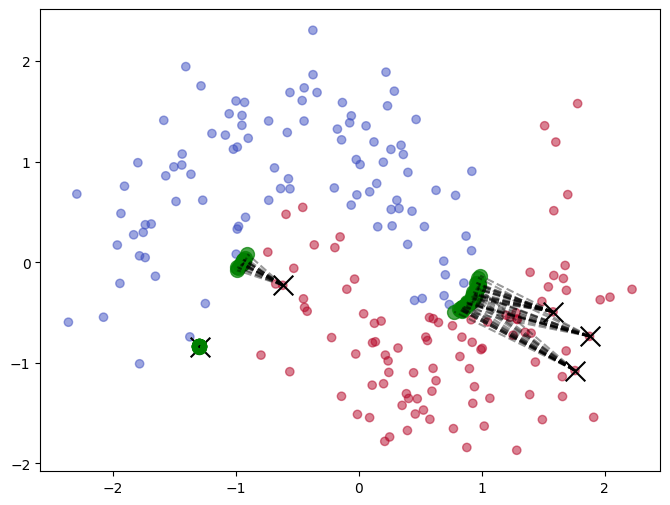

In [51]:
# plot the cal set
model = models["mlp"]
plt.figure(figsize=(8,6))
plt.scatter(splits['X_calibration'].values[:,0],splits['X_calibration'].values[:,1],c=model.predict(splits['X_calibration']),cmap='coolwarm',alpha=0.5)

# choose 5 random points
import random
random_indices = random.sample(range(len(splits['X_calibration'])), 5)
for idx in random_indices:
    instance = splits['X_calibration'].iloc[idx].values.reshape(1, -1)
    cf = counterfactuals["mlp"][idx]["counterfactuals"].values[:,:-1]
    plt.scatter(instance[0,0],instance[0,1],c='black',s=200,marker='x')
    plt.scatter(cf[:,0],cf[:,1],c='green',s=100,marker='o',alpha=0.7)
    # plot the lines 
    for point in cf:
        plt.plot([instance[0,0], point[0]], [instance[0,1], point[1]], 'k--', alpha=0.4)

In [24]:
from src.growingspheres.growingspheres import counterfactuals as cf

In [ ]:
idx = np.random.randint(splits['X_test'].shape[0])
obs = splits['X_test'].iloc[idx, :].values.reshape(1, -1)
clf = models[chosen_model]
CF = cf.CounterfactualExplanation(obs, clf.predict, method='GS')
CF.fit(n_in_layer=200, first_radius=1.1, dicrease_radius=2.0, sparse=True, verbose=True, num_enemies=32)

49 ennemies found in initial hyperball.
Zooming in...
39 ennemies found in initial hyperball.
Zooming in...
29 ennemies found in initial hyperball.
Zooming in...
26 ennemies found in initial hyperball.
Zooming in...
15 ennemies found in initial hyperball.
Zooming in...
8 ennemies found in initial hyperball.
Zooming in...
11 ennemies found in initial hyperball.
Zooming in...
6 ennemies found in initial hyperball.
Zooming in...
1 ennemies found in initial hyperball.
Zooming in...
0 ennemies found in initial hyperball.
Expanding hypersphere...
Final number of iterations:  1
Final radius:  (0.4240976183724846, 0.809640907802016)
Final number of ennemies:  22
Feature selection...
Reduced 0 coordinates
Feature selection...
Reduced 0 coordinates
Feature selection...
Reduced 1 coordinates
Feature selection...
Reduced 1 coordinates
Feature selection...
Reduced 1 coordinates
Feature selection...
Reduced 1 coordinates
Feature selection...
Reduced 1 coordinates
Feature selection...
Reduced 1 coord

In [72]:
CF = cf.CounterfactualExplanation(obs, clf.predict, method='GS')
CF.fit(n_in_layer=200, first_radius=1.1, dicrease_radius=2.0, sparse=True, verbose=False, num_enemies=32)

In [68]:
np.array(CF.enemies).shape

(33, 2)

In [69]:
len(CF.enemies)

33

In [70]:
clf.predict(CF.enemies),clf.predict(obs)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([1]))

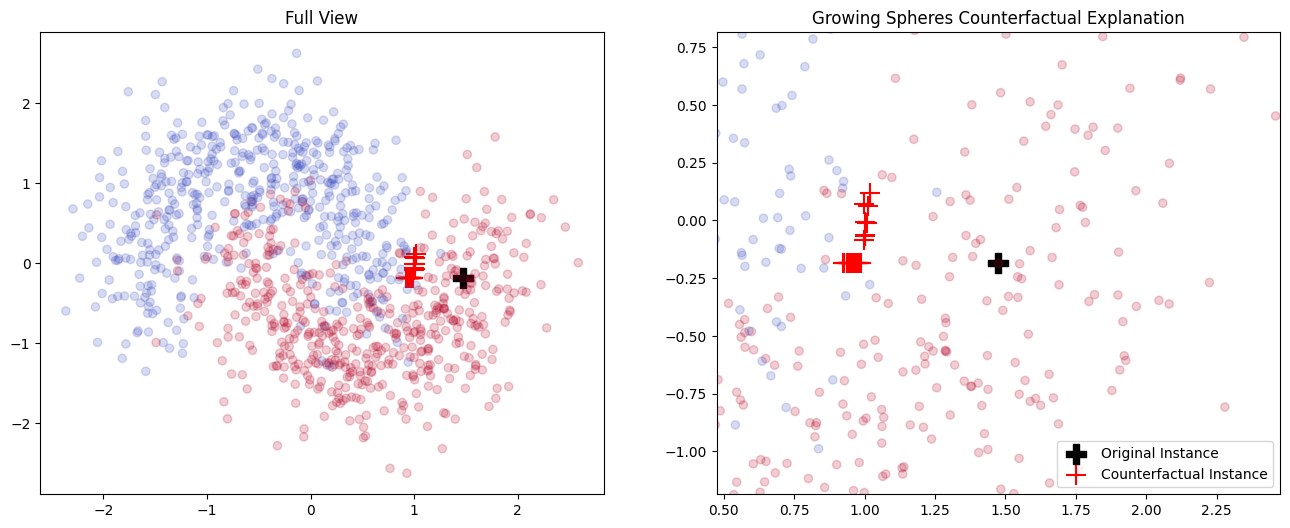

In [71]:
# plot the dataset
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
X = processed_data[0].values
y = processed_data[1].values
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(16,6))
full_ax = ax[0]
focus_ax = ax[1]
full_ax.scatter(obs[0,0],obs[0,1],c='black',s=200,marker='P',label='Original Instance')
full_ax.scatter(np.array(CF.enemies)[:,0],np.array(CF.enemies)[:,1],c='red',s=200,marker='+',label='Counterfactual Instance')
ylims, xlims = full_ax.get_ylim(),full_ax.get_xlim()


full_ax.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',alpha=0.2)
focus_ax.scatter(obs[0,0],obs[0,1],c='black',s=200,marker='P',label='Original Instance')
focus_ax.scatter(np.array(CF.enemies)[:,0],np.array(CF.enemies)[:,1],c='red',s=200,marker='+',label='Counterfactual Instance')
focus_ax.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',alpha=0.2)
focus_ax.set_xlim(obs[0,0]-1,obs[0,0]+1)
focus_ax.set_ylim(obs[0,1]-1,obs[0,1]+1)
full_ax.set_title('Full View')
focus_ax.set_title('Focus View')

plt.legend()
plt.title('Growing Spheres Counterfactual Explanation')


plt.show()

In [55]:

r = cf_generator.generate_counterfactuals(models=models,
                                      X_calibration=splits['X_calibration'][1:3],
                                      y_calibration=splits['y_calibration'][1:3],
                                      dt_name='my_ddataset')

NameError: name 'cf_generator' is not defined

In [45]:
None in splits['X_calibration']


False

In [16]:
cf_method = 'random'
experiments = {m:{meth:[0,[np.inf]] for meth in ["random","kdtree","genetic"]} for m in ["mlp","xgboost","random_forest","lgbm"]}
experiments,cf_method 

({'mlp': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]},
  'xgboost': {'random': [0, [inf]],
   'kdtree': [0, [inf]],
   'genetic': [0, [inf]]},
  'random_forest': {'random': [0, [inf]],
   'kdtree': [0, [inf]],
   'genetic': [0, [inf]]},
  'lgbm': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]}},
 'random')

In [17]:
'''# now we redo all that the counterfactuals generator object does
# for the sake of clarity and checking the time
import dice_ml
reference_data = splits['X_train'].sample(1)

reference_data["target"] = 1

# reference_data = splits['X_train'].copy()
# reference_data["target"] = splits['y_train']
dice_data = dice_ml.Data(dataframe=reference_data,#pd.DataFrame([], columns=splits['X_train'].columns+["target"]),
                         continuous_features=splits['X_train'].columns.to_list(),
                         categorical_features=[],
                         outcome_name='target',
                         dataset_name='german_credit')

dice_model = dice_ml.Model(model=models["mlp"],
                            backend="sklearn")
explainer = dice_ml.Dice(dice_data, dice_model, method=cf_method)

counterfactuals = cf_generator.generate_counterfactuals(
        models,
        splits['X_calibration'],
        splits['y_calibration'],
        "random",
        dt_name=dataset_name
    )'''

'# now we redo all that the counterfactuals generator object does\n# for the sake of clarity and checking the time\nimport dice_ml\nreference_data = splits[\'X_train\'].sample(1)\n\nreference_data["target"] = 1\n\n# reference_data = splits[\'X_train\'].copy()\n# reference_data["target"] = splits[\'y_train\']\ndice_data = dice_ml.Data(dataframe=reference_data,#pd.DataFrame([], columns=splits[\'X_train\'].columns+["target"]),\n                         continuous_features=splits[\'X_train\'].columns.to_list(),\n                         categorical_features=[],\n                         outcome_name=\'target\',\n                         dataset_name=\'german_credit\')\n\ndice_model = dice_ml.Model(model=models["mlp"],\n                            backend="sklearn")\nexplainer = dice_ml.Dice(dice_data, dice_model, method=cf_method)\n\ncounterfactuals = cf_generator.generate_counterfactuals(\n        models,\n        splits[\'X_calibration\'],\n        splits[\'y_calibration\'],\n        "ra

In [15]:
'''

for i in range(total_samples):
        e = splits['X_calibration'].loc[[i]]
        try:
            res = explainer.generate_counterfactuals(e, total_CFs=32, desired_class="opposite",verbose=False)
            print(len(res.cf_examples_list[0].final_cfs_df))

            found+=1
        except Exception as exc:
            print(exc)
            continue
            #print(exc,", skipping")
print("Found",found,"counterfactuals", "out of",total_samples)
print("percentage",found/total_samples)'''

'\n\nfor i in range(total_samples):\n        e = splits[\'X_calibration\'].loc[[i]]\n        try:\n            res = explainer.generate_counterfactuals(e, total_CFs=32, desired_class="opposite",verbose=False)\n            print(len(res.cf_examples_list[0].final_cfs_df))\n\n            found+=1\n        except Exception as exc:\n            print(exc)\n            continue\n            #print(exc,", skipping")\nprint("Found",found,"counterfactuals", "out of",total_samples)\nprint("percentage",found/total_samples)'

In [16]:
experiments

{'mlp': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]},
 'xgboost': {'random': [0, [inf]],
  'kdtree': [0, [inf]],
  'genetic': [0, [inf]]},
 'random_forest': {'random': [0, [inf]],
  'kdtree': [0, [inf]],
  'genetic': [0, [inf]]},
 'lgbm': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]}}

In [19]:
found=0
total_samples = 25
percs = [1,25,50,100]
full_experiments = {p:{} for p in percs}
results = {}
for percentage in percs:
    results[percentage] = {}
    #########################
    #### CHOOSE THE DATA ####
    #########################
    if percentage==1:
        reference_data = splits['X_train'].sample(1)
        reference_data["target"] = 1
    else:
        # choose a percentage of the training data

        choosen_idxs = np.random.choice(splits['X_train'].index, int(len(splits['X_train'])*percentage/100))
        reference_data = splits['X_train'].loc[choosen_idxs]
        reference_data["target"] = splits['y_train'].loc[choosen_idxs]
    dice_data = dice_ml.Data(dataframe=reference_data,#pd.DataFrame([], columns=splits['X_train'].columns+["target"]),
                            continuous_features=splits['X_train'].columns.to_list(),
                            categorical_features=[],
                            outcome_name='target',
                            dataset_name='german_credit')

    #########################
    #### CHOOSE THE MODEL ###
    #########################
    experiments = {m:{meth:[0,[np.inf]] for meth in ["random","kdtree","genetic"]} for m in ["mlp","xgboost","random_forest","lgbm"]}
    for cf_method in ["random","kdtree"]:#,"genetic"]: 
        results[percentage][cf_method] = {}
        for model in ["random_forest"]:
            results[percentage][cf_method][model] = {}
            print("Generating counterfactuals for",model,"with",cf_method,"method with",percentage,"% of the training data")
            dice_model = dice_ml.Model(model=models["mlp"],
                                    backend="sklearn")
            explainer = dice_ml.Dice(dice_data, dice_model, method=cf_method)

            found=0
            times = []
            founded = []
            oupts = []
            for i in range(total_samples):
                e = splits['X_calibration'].loc[[i]]
                
                try:
                    start = time.time()
                    res = explainer.generate_counterfactuals(e, total_CFs=32, desired_class="opposite",verbose=False)
                    print(len(res.cf_examples_list[0].final_cfs_df))
                    oupts.append(res)
                    found+=1
                    founded.append(1)
                except Exception as exc:
                    print(exc)
                    founded.append(0)
                    continue

                elapsed = time.time()-start
                
                '''
                # to test the time and the founds invent the data
                foundq = np.random.randint(0,2)
                found+=foundq
                founded.append(foundq)
                elapsed = np.random.rand()*10
                '''
                times.append(elapsed)
            print("Found",found,"counterfactuals", "out of",total_samples)
            print("percentage",found/total_samples)

            experiments[model][cf_method][0] = np.array(founded)
            experiments[model][cf_method][1] = np.array(times)
            results[percentage][cf_method][model]["found"] = founded
            results[percentage][cf_method][model]["times"] = times
            results[percentage][cf_method][model]["outputs"] = oupts
    full_experiments[percentage] = experiments


Generating counterfactuals for random_forest with random method with 1 % of the training data


100%|██████████| 1/1 [00:00<00:00,  3.58it/s]


32


100%|██████████| 1/1 [00:00<00:00,  3.60it/s]


32


...

32


100%|██████████| 1/1 [01:49<00:00, 109.25s/it]


32


100%|██████████| 1/1 [03:44<00:00, 224.38s/it]

32
Found 25 counterfactuals out of 25
percentage 1.0


In [21]:
import seaborn as sns

In [46]:
def write_time(s):
        s = np.round(s,2)
        if s<60:
            return str(s)+"s"
        elif s<60*60:
            s = np.round(s/60,2)
            return str(s)+"m"
        else:
            s = np.round(s/60/60,2)
            return str(s)+"h"

In [76]:
percs

[1, 25, 50, 100]

100.0
100.0
100.0
100.0
Total time needed: 7.72s 36.45m 42.87m 53.12m


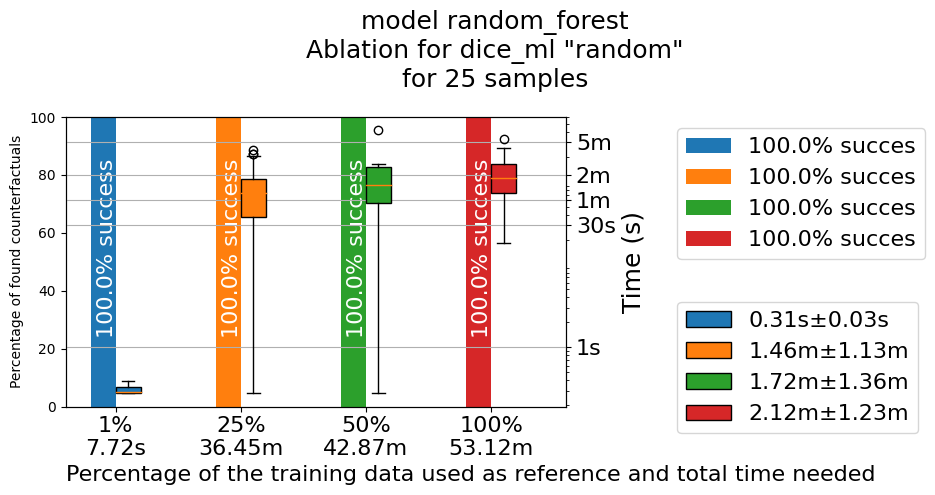

In [79]:
# define the figure
for meth in ["random"]:
    fig, ax = plt.subplots(1,1,figsize=(10,5))
    ax2 = ax.twinx()
    all_percs = []
    all_times = []
    labs = []
    boxes = []

    for j,i in enumerate(percs):
        # get the experiment:
        exp = full_experiments[i]    
        # plot the bars relatively to the total samples
        # at the j-th position
        percentages = exp["random_forest"]["random"][0].sum()/total_samples*100
        print(percentages)
        ax.bar(j-0.2,percentages,0.2,label=str(round(percentages,2))+"% succes")
        text_position = (j-0.25,percentages/4)
        # write in white the percentage of found counterfactuals
        ax.text(*text_position,str(round(percentages,2))+"% success",color="white",fontsize=16,rotation=90)
        ax.set_ylabel("Percentage of found counterfactuals")
        # plot the boxplot of the times
        # get the ax2
        cmap = sns.color_palette("tab10", as_cmap=True)
        times = exp["random_forest"][meth][1]
        pathc = ax2.boxplot(times,positions=[j],widths=0.2,patch_artist=True,showfliers=True)
        labs.append(write_time(np.mean(times))+"±"+
                    write_time(np.std(times)))
        all_times.append(times)
        for patch in pathc['boxes']:
            patch.set_facecolor(cmap(j))
        boxes.append(pathc["boxes"][0])
        ax2.set_ylabel("Time (s)",fontsize=18)
        all_percs.append(percentages)
    
    ax.set_ylim(0,100)
    # make the legend external
    ax.legend(loc='upper left', bbox_to_anchor=(1.2, 1),fontsize=16)
    ax2.legend(boxes,labs,loc='upper left', bbox_to_anchor=(1.2, 0.4),fontsize=16)

    # set the y ticks to be at 1 second, 30, 60, 120.
    # use as labels 1s, 30s, 1m, 2m
    ax2.set_yscale("log")
    ax2.set_yticks([1,30,60,120,60*5])
    ax2.set_yticklabels(["1s","30s","1m","2m","5m"],fontsize=16)
    all_times_s = [ii.sum() for ii in all_times]
    
    additional_label = "Total time needed: "+" ".join(map(write_time,all_times_s))
    xticks = [str(p)+"%\n"+(t_s) for p,t_s in zip(percs,map(write_time,all_times_s))]
    #ax.set_xticks(np.arange(len(percs))-.1,[str(p)+"%" for p in percs],fontsize=16)
    ax.set_xticks(np.arange(len(percs))-.1,xticks,fontsize=16)
    ax.set_xlabel("Percentage of the training data used as reference and total time needed",fontsize=16,loc="left")
    plt.suptitle("model random_forest\n Ablation for dice_ml \""+str(meth)+"\" \nfor 25 samples",fontsize=18)
    plt.tight_layout()
    # show the grid
    plt.grid(True)
    date = time.strftime("%Y-%m-%d-%H-%M-%S")

    spath = f"plots/ablation_random_forest_{meth}_dice_ml_"+date+".pdf"
    plt.savefig(spath)
    print(additional_label)

In [72]:
date = time.strftime("%Y-%m-%d-%H-%M-%S")
date.replace("-","")

'20241204185530'